In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [5]:
df = sns.load_dataset("titanic") #i am loading the data
#now we begin preprocessing on the dataset, starting with imputation where we fill the missing values, so we firdt see places with missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [36]:
#now imputation
df["age"] = df["age"].fillna(df["age"].median()) #for the age column
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0]) #for the embarked column
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0]) # for embbark_town
#it would be a smart decision to drop deck cause there are so much missing values, and i need practice on how to drop a column
#df.drop(columns=["deck"], inplace=True) #we are dropping deck
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

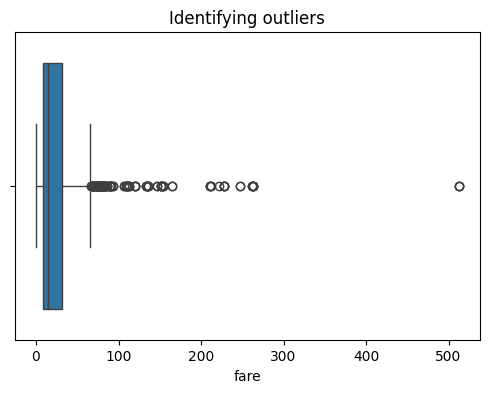

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["fare"])
plt.title("Identifying outliers")
plt.show()

In [45]:
#since we are done with imputation next is encoding(one hot encoding)
#we converting the sex to numbers
df = pd.get_dummies(df, columns=["sex"], drop_first=True)
# we commented the code cause we can onlyy run it once
#now we do embarked
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,True,False,True


In [47]:
#and finally scaling, we are scaling age and fare
scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,-0.565736,1,0,-0.502445,Third,man,True,Southampton,no,False,True,False,True
1,1,1,0.663861,1,0,0.786845,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,-0.258337,0,0,-0.488854,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,0.433312,1,0,0.420730,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0.433312,0,0,-0.486337,Third,man,True,Southampton,no,True,True,False,True
